In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("unemployment/Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [2]:
print(df.info())
print(df.isnull().sum()) #data cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None
Region                                      0
 

In [3]:
df[" Date"] = pd.to_datetime(df[" Date"])

In [4]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [5]:
#analyzing unemployment rate data representing unemployed people percentage
#data exploration
print("Mean Unemployment Rate:", df[' Estimated Unemployment Rate (%)'].mean()) 
print("Max Unemployment Rate:", df[' Estimated Unemployment Rate (%)'].max())
print("Min Unemployment Rate:", df[' Estimated Unemployment Rate (%)'].min())

Mean Unemployment Rate: 12.236928838951311
Max Unemployment Rate: 75.85
Min Unemployment Rate: 0.5


In [6]:
df = df.sort_values(" Date")

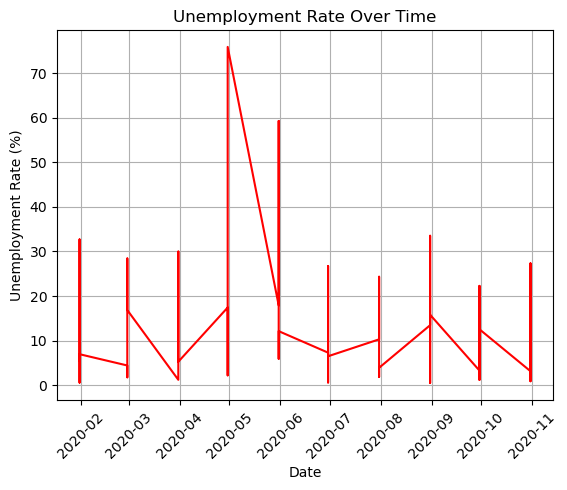

In [7]:
#visualizations to see diffrent trends
plt.figure()
plt.plot(df[' Date'], df[' Estimated Unemployment Rate (%)'],color ='red')
plt.grid()
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()


Region-wise Average Unemployment:
Region
Meghalaya            3.866000
Assam                4.856000
Gujarat              6.376000
Odisha               6.462000
Telangana            6.833000
Madhya Pradesh       6.854000
Karnataka            7.668000
Chhattisgarh         7.819000
Maharashtra          7.979000
Andhra Pradesh       8.664000
Kerala               9.434000
Uttar Pradesh        9.737000
Sikkim               9.792500
West Bengal         10.192000
Uttarakhand         11.156000
Punjab              11.981000
Goa                 12.167000
Tamil Nadu          12.187000
Rajasthan           15.868000
Himachal Pradesh    16.065000
Jammu & Kashmir     16.477778
Puducherry          17.942000
Delhi               18.414000
Bihar               19.471000
Jharkhand           19.539000
Tripura             25.055000
Haryana             27.477000
Name:  Estimated Unemployment Rate (%), dtype: float64


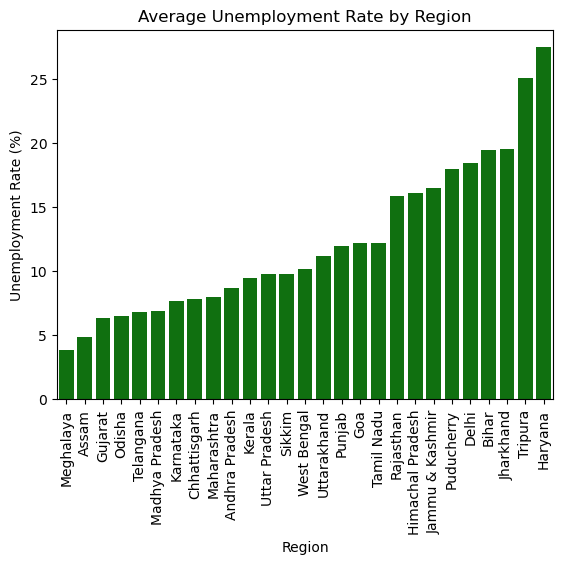

In [8]:
region_avg = df.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values()

print("\nRegion-wise Average Unemployment:")
print(region_avg)

plt.figure()
sns.barplot(x=region_avg.index, y=region_avg.values,color='green')
plt.xticks(rotation=90)
plt.title("Average Unemployment Rate by Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [9]:
# Covid-19 impact Analysis on employment rates(before and during covid)
df['Year'] = df[' Date'].dt.year

pre_covid = df[df['Year'] < 2020]
covid = df[df['Year'] >= 2020]

print("\nPre-Covid Average:", pre_covid[' Estimated Unemployment Rate (%)'].mean())
print("During Covid Average:", covid[' Estimated Unemployment Rate (%)'].mean())



Pre-Covid Average: nan
During Covid Average: 12.23692883895131



Monthly Average Unemployment:
Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name:  Estimated Unemployment Rate (%), dtype: float64


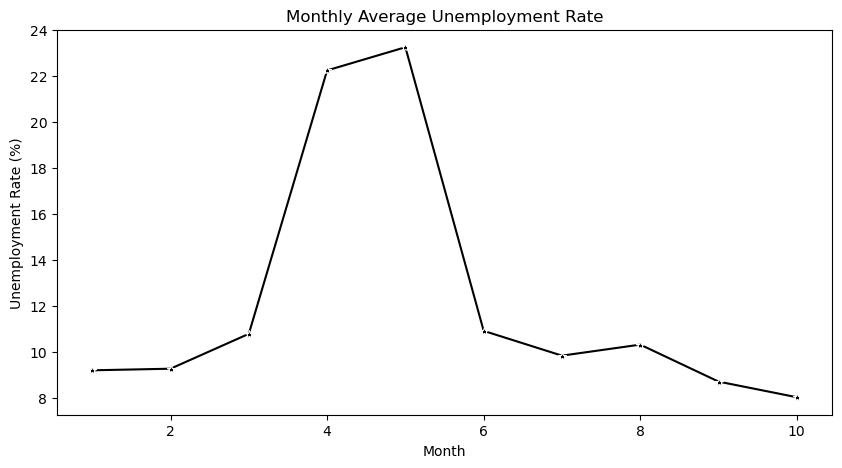

In [10]:
# Key patterns or Seasonal trends in data 
df['Month'] = df[' Date'].dt.month

monthly_avg = df.groupby('Month')[' Estimated Unemployment Rate (%)'].mean()

print("\nMonthly Average Unemployment:")
print(monthly_avg)

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values,color = 'black', marker='*')
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.show()


Top 5 Highest Unemployment Cases:
         Region       Date  Frequency   Estimated Unemployment Rate (%)  \
172  Puducherry 2020-04-30          M                             75.85   
103   Jharkhand 2020-05-31          M                             59.23   
173  Puducherry 2020-05-31          M                             58.19   
210  Tamil Nadu 2020-04-30          M                             49.83   
102   Jharkhand 2020-04-30          M                             47.09   

      Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
172               117542                                     39.30    South   
103              4145385                                     37.92     East   
173               172308                                     33.19    South   
210              9719167                                     29.63    South   
102              5335262                                     37.69     East   

     longitude  latitude  Year  Month  

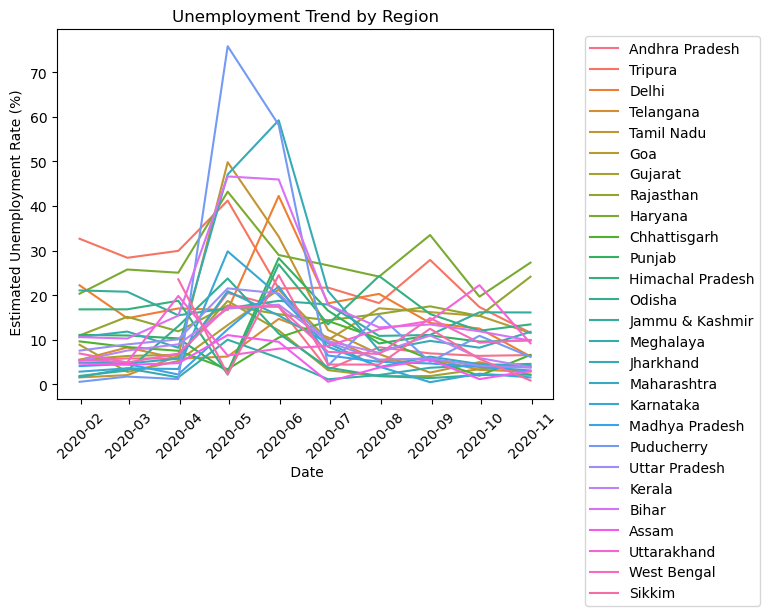

In [11]:
# Top 5 Highest Unemployment Cases
top5 = df.sort_values(by=' Estimated Unemployment Rate (%)', ascending=False).head()

print("\nTop 5 Highest Unemployment Cases:")
print(top5)

# Correlation Analysis (relationship between Estimated Unemployment Rate (%) and Estimated Employed)
correlation = df[[' Estimated Unemployment Rate (%)', ' Estimated Employed']].corr()

print("\nCorrelation between Employment & Unemployment:")
print(correlation)

# Visualizations 
plt.figure()
sns.lineplot(data=df, x=' Date', y=' Estimated Unemployment Rate (%)', hue='Region')
plt.legend(bbox_to_anchor=(1.05,1),loc = 'upper left')
plt.title("Unemployment Trend by Region")
plt.xticks(rotation=45)
plt.show()

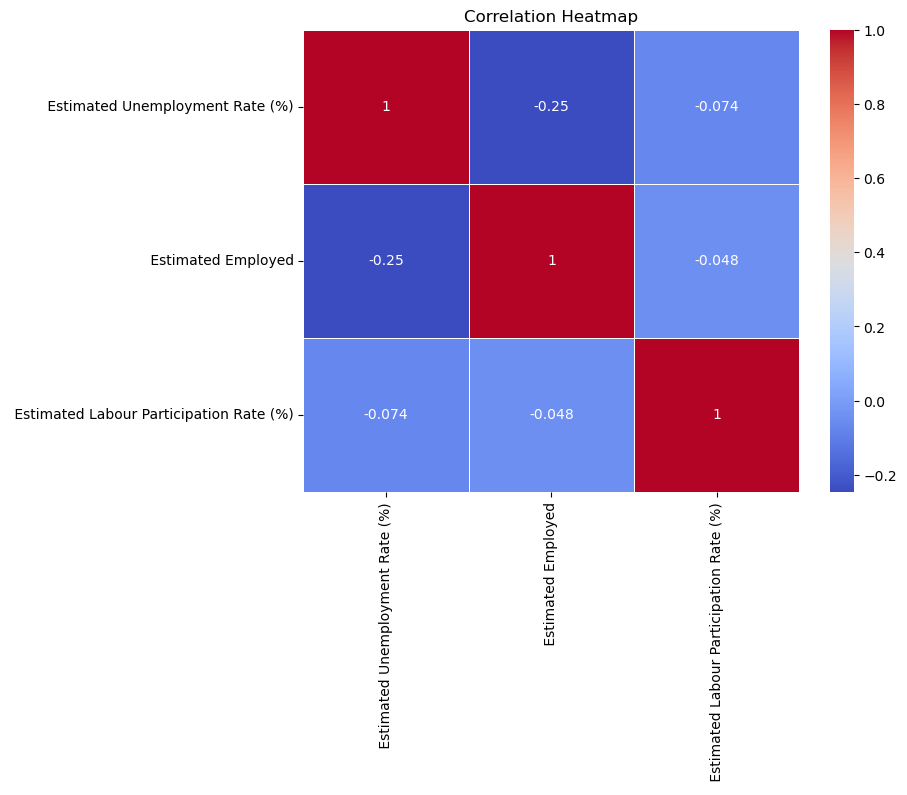

In [14]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[[' Estimated Unemployment Rate (%)',
           ' Estimated Employed',
           ' Estimated Labour Participation Rate (%)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
print("\nINSIGHTS:")
print("1. Mean unemployment rate was 12.24%, showing moderate unemployment.")
print("2. Maximum unemployment rate reached 75.85%, indicating severe job loss in some regions.")
print("3. Minimum unemployment rate was only 0.5%, showing better conditions in certain areas.")
print("4. During Covid, average unemployment rate was 12.24%, showing pandemic impact on jobs.")
print("5. Puducherry recorded the highest unemployment rate (75.85%) in April 2020.")
print("6. Jharkhand and Tamil Nadu also faced very high unemployment during lockdown months.")
print("7. Employment and unemployment had a negative correlation (-0.245), meaning when employment decreases, unemployment increases.")
print("8. South and East regions were heavily affected in peak Covid months.")
print("9. These insights can help the government plan job creation and economic recovery policies.")


INSIGHTS:
1. Mean unemployment rate was 12.24%, showing moderate unemployment.
2. Maximum unemployment rate reached 75.85%, indicating severe job loss in some regions.
3. Minimum unemployment rate was only 0.5%, showing better conditions in certain areas.
4. During Covid, average unemployment rate was 12.24%, showing pandemic impact on jobs.
5. Puducherry recorded the highest unemployment rate (75.85%) in April 2020.
6. Jharkhand and Tamil Nadu also faced very high unemployment during lockdown months.
7. Employment and unemployment had a negative correlation (-0.245), meaning when employment decreases, unemployment increases.
8. South and East regions were heavily affected in peak Covid months.
9. These insights can help the government plan job creation and economic recovery policies.
